### Imports

In [17]:
from fundus_dataset import AugmentPair, FundusVesselDataset
from torch.utils.data import DataLoader
import torch.nn as nn
import torch
import matplotlib.pyplot as plt
from torch.utils.data import Subset


### Testing the Dataset

In [18]:
# -------------------------
# Paths
# -------------------------

img_dir = "fundus/train/Original/"
mask_dir = "fundus/train/Ground truth"

# -------------------------
# Dataset
# -------------------------

train_dataset = FundusVesselDataset(
    img_dir=img_dir,
    mask_dir=mask_dir,
    transform=AugmentPair(crop_size=(512, 512)),
)

# Subset the dataset to "sample_size"
sample_size = 32

# If sample_size is greater than the dataset, use the entire dataset
sample_size = min(sample_size, len(train_dataset))

# Subset the dataset to the sample size
subset = Subset(train_dataset, list(range(sample_size)))

# -------------------------
# DataLoader
# -------------------------

train_loader = DataLoader(
    subset,
    batch_size=8,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
)

# -------------------------
# Debug shape check
# -------------------------

images, masks = next(iter(train_loader))

print("Images shape:", images.shape)
print("Masks shape:", masks.shape)
print("Images dtype:", images.dtype)
print("Masks dtype:", masks.dtype)
print("Image min/max:", images.min().item(), images.max().item())
print("Mask unique values:", torch.unique(masks))


/home/user/bettiloss/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Images shape: torch.Size([8, 3, 512, 512])
Masks shape: torch.Size([8, 1, 512, 512])
Images dtype: torch.float32
Masks dtype: torch.float32
Image min/max: 0.0 1.0
Mask unique values: tensor([0., 1.])


### Matplotlib to test out the DataLoader

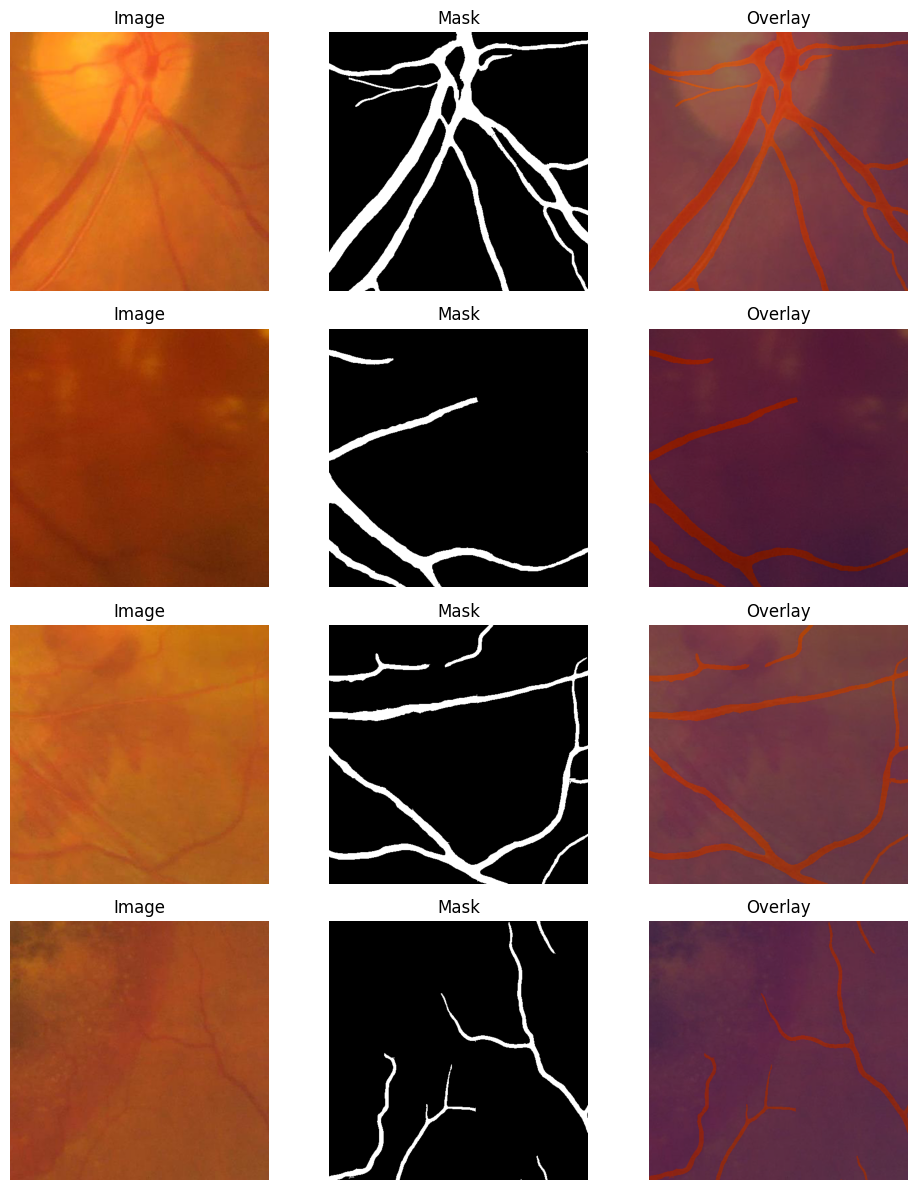

In [19]:
from matplotlib import pyplot as plt

fig, axes = plt.subplots(4, 3, figsize=(10, 12))

for i in range(4):
    img = images[i].permute(1, 2, 0).cpu().numpy()
    mask = masks[i].squeeze(0).cpu().numpy()

    axes[i, 0].imshow(img)
    axes[i, 0].set_title("Image")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(mask, cmap="gray")
    axes[i, 1].set_title("Mask")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(img)
    axes[i, 2].imshow(mask, cmap="jet", alpha=0.4)
    axes[i, 2].set_title("Overlay")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

### U-Net Training Code

In [21]:
from monai.networks.nets import UNet
from monai.losses import DiceLoss
import torch.nn as nn
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# We'll use a U-Net model with 5 levels of downsampling and upsampling
model = UNet(
    spatial_dims=2,
    in_channels=3,
    out_channels=1,
    channels=(16, 32, 64, 128, 256),
    strides=(2, 2, 2, 2),
    num_res_units=2,
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
epochs = 3

dice_loss, bce_loss = DiceLoss(sigmoid=True), nn.BCEWithLogitsLoss()
w_dice, w_bce = 0.5, 0.5

history = []

for epoch in range(epochs):
    model.train()

    total_loss = 0.0
    total_dice = 0.0
    total_bce = 0.0
    n_samples = 0

    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        logits = model(images)

        d_loss = dice_loss(logits, masks)
        b_loss = bce_loss(logits, masks)
        loss = w_dice * d_loss + w_bce * b_loss

        loss.backward()
        optimizer.step()

        batch_size = images.size(0)
        total_loss += loss.item() * batch_size
        total_dice += d_loss.item() * batch_size
        total_bce += b_loss.item() * batch_size
        n_samples += batch_size

    avg_loss = total_loss / n_samples
    avg_dice = total_dice / n_samples
    avg_bce = total_bce / n_samples

    history.append({
        "epoch": epoch + 1,
        "loss": avg_loss,
        "dice_loss": avg_dice,
        "bce_loss": avg_bce,
    })

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"loss={avg_loss:.4f} | "
        f"dice={avg_dice:.4f} | "
        f"bce={avg_bce:.4f}"
    )

Epoch 1/3 | loss=0.8058 | dice=0.8405 | bce=0.7711
Epoch 2/3 | loss=0.7651 | dice=0.8318 | bce=0.6984
Epoch 3/3 | loss=0.7227 | dice=0.7840 | bce=0.6614


### Weighted Loss, Dice Loss, BCE Loss Graphs